# Chess Win Predictor

This notebook aims to predict the outcome of a chess game (White wins, Black wins, or Draw) based on various features such as player ratings, time control, and opening moves.

## 1. Data Loading
First, we download the dataset from Kaggle and locate the CSV file.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arevel/chess-games")

print("Path to dataset files:", path)

Path to dataset files: /Users/theenukabandara/.cache/kagglehub/datasets/arevel/chess-games/versions/1


In [2]:
!cd /root/.cache/kagglehub/datasets/arevel/chess-games/versions/1 && pwd && ls

zsh:cd:1: no such file or directory: /root/.cache/kagglehub/datasets/arevel/chess-games/versions/1


In [3]:
import os 

csv_file = os.path.join(path, "chess_games.csv")

## 2. Data Exploration
Load the dataset into a pandas DataFrame and inspect its structure, columns, and data types.

In [4]:
import pandas as pd

df_raw = pd.read_csv(csv_file)
# df = df.sample(n=100000, random_state=42)
df_raw.head()

,Event,White,Black,Result,UTCDate,UTCTime,WhiteElo,BlackElo,WhiteRatingDiff,BlackRatingDiff,ECO,Opening,TimeControl,Termination,AN
0,Classical,eisaaaa,HAMID449,1-0,2016.06.30,22:00:01,1901,1896,11.0,-11.0,D10,Slav Defense,300+5,Time forfeit,1. d4 d5 2. c4 c6 3. e3 a6 4. Nf3 e5 5. cxd5 e...
1,Blitz,go4jas,Sergei1973,0-1,2016.06.30,22:00:01,1641,1627,-11.0,12.0,C20,King's Pawn Opening: 2.b3,300+0,Normal,1. e4 e5 2. b3 Nf6 3. Bb2 Nc6 4. Nf3 d6 5. d3 ...
2,Blitz tournament,Evangelistaizac,kafune,1-0,2016.06.30,22:00:02,1647,1688,13.0,-13.0,B01,Scandinavian Defense: Mieses-Kotroc Variation,180+0,Time forfeit,1. e4 d5 2. exd5 Qxd5 3. Nf3 Bg4 4. Be2 Nf6 5....
3,Correspondence,Jvayne,Wsjvayne,1-0,2016.06.30,22:00:02,1706,1317,27.0,-25.0,A00,Van't Kruijs Opening,-,Normal,1. e3 Nf6 2. Bc4 d6 3. e4 e6 4. Nf3 Nxe4 5. Nd...
4,Blitz tournament,kyoday,BrettDale,0-1,2016.06.30,22:00:02,1945,1900,-14.0,13.0,B90,"Sicilian Defense: Najdorf, Lipnitsky Attack",180+0,Time forfeit,1. e4 c5 2. Nf3 d6 3. d4 cxd4 4. Nxd4 Nf6 5. N...


In [5]:
df_raw.columns

Index(['Event', 'White', 'Black', 'Result', 'UTCDate', 'UTCTime', 'WhiteElo',
       'BlackElo', 'WhiteRatingDiff', 'BlackRatingDiff', 'ECO', 'Opening',
       'TimeControl', 'Termination', 'AN'],
      dtype='object')

In [6]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6256184 entries, 0 to 6256183
Data columns (total 15 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Event            object 
 1   White            object 
 2   Black            object 
 3   Result           object 
 4   UTCDate          object 
 5   UTCTime          object 
 6   WhiteElo         int64  
 7   BlackElo         int64  
 8   WhiteRatingDiff  float64
 9   BlackRatingDiff  float64
 10  ECO              object 
 11  Opening          object 
 12  TimeControl      object 
 13  Termination      object 
 14  AN               object 
dtypes: float64(2), int64(2), object(11)
memory usage: 716.0+ MB


### 2.1 Data Visualization
Before modifying the data, let's visualize the target variable (`Result`) and the distribution of player ratings to better understand our dataset.

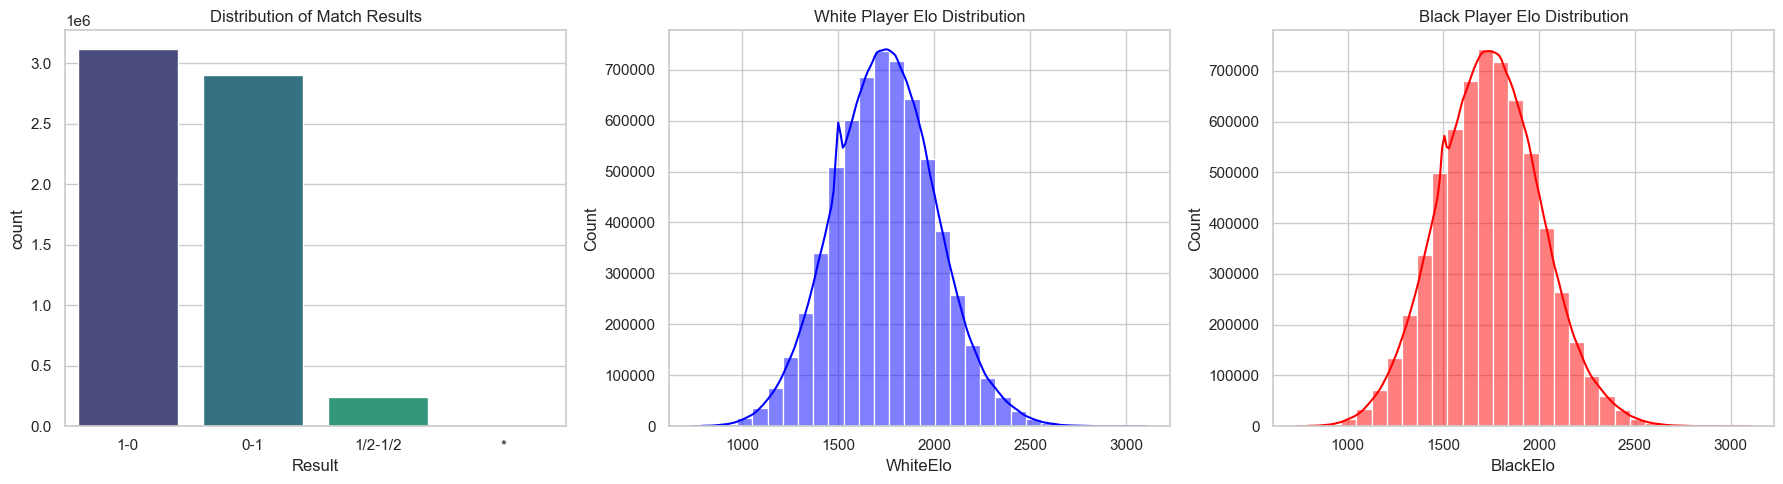

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Match Results distribution
# Add hue and legend=False to suppress seaborn FutureWarninge='Result' and legend=False to fix the Seaborn Future Warning
sns.countplot(data=df_raw, x='Result', hue='Result', ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Distribution of Match Results')

# Plot 2: White Elo Distribution
sns.histplot(df_raw['WhiteElo'], bins=30, kde=True, ax=axes[1], color='blue')
axes[1].set_title('White Player Elo Distribution')

# Plot 3: Black Elo Distribution
sns.histplot(df_raw['BlackElo'], bins=30, kde=True, ax=axes[2], color='red')
axes[2].set_title('Black Player Elo Distribution')

plt.tight_layout()
plt.show()

## 3. Feature Engineering
Create a new feature `EloDifference` which represents the difference in Elo ratings between the White and Black players. This could be a strong predictor of the game outcome.

In [8]:
df_raw['EloDifference'] = df_raw['WhiteElo'] - df_raw['BlackElo']


## 4. Data Cleaning
Drop columns that are not useful for prediction or contain redundant information. Also, filter out rows with invalid or missing values in critical columns like `TimeControl` and `Result`.

In [9]:
columns_to_drop = ['Event','White','Black','UTCDate','UTCTime','Opening','Termination','AN','WhiteRatingDiff','BlackRatingDiff']

df_cleaned = df_raw.drop(columns=columns_to_drop)
df_cleaned.head()

,Result,WhiteElo,BlackElo,ECO,TimeControl,EloDifference
0,1-0,1901,1896,D10,300+5,5
1,0-1,1641,1627,C20,300+0,14
2,1-0,1647,1688,B01,180+0,-41
3,1-0,1706,1317,A00,-,389
4,0-1,1945,1900,B90,180+0,45


In [10]:
df_cleaned = df_cleaned[df_cleaned['TimeControl'] != '-']
df_cleaned = df_cleaned[df_cleaned['Result'] != '*']

In [11]:
df_cleaned.head()

,Result,WhiteElo,BlackElo,ECO,TimeControl,EloDifference
0,1-0,1901,1896,D10,300+5,5
1,0-1,1641,1627,C20,300+0,14
2,1-0,1647,1688,B01,180+0,-41
4,0-1,1945,1900,B90,180+0,45
5,0-1,1773,1809,C27,180+0,-36


## 5. Data Preprocessing
Encode categorical variables like `Result`, `ECO` (Encyclopedia of Chess Openings), and `TimeControl` into numerical values using `LabelEncoder` so they can be used by machine learning models. Drop any remaining missing values.

In [12]:
from sklearn.preprocessing import LabelEncoder

le_result = LabelEncoder()
df_cleaned['Result'] = le_result.fit_transform(df_cleaned['Result'])

le_eco = LabelEncoder()
df_cleaned['ECO'] = le_eco.fit_transform(df_cleaned['ECO'])

le_time = LabelEncoder()
df_cleaned['TimeControl'] = le_time.fit_transform(df_cleaned['TimeControl'])

df_cleaned = df_cleaned.dropna()

print(df_cleaned.head())



   Result  WhiteElo  BlackElo  ECO  TimeControl  EloDifference
0       1      1901      1896  310          408              5
1       0      1641      1627  220          384             14
2       1      1647      1688  101          203            -41
4       0      1945      1900  190          203             45
5       0      1773      1809  227          203            -36


In [13]:
# check lables for Result column

print("Unique labels in 'Result' column:", df_cleaned['Result'].unique())

Unique labels in 'Result' column: [1 0 2]


## 6. Handling Class Imbalance
The dataset might have an unequal number of wins for White, Black, and Draws. We balance the dataset by downsampling the majority classes to match the number of samples in the minority class. This prevents the model from being biased towards the majority class.

In [14]:
from sklearn.utils import resample

df_black = df_cleaned[df_cleaned['Result'] == 0]
df_white = df_cleaned[df_cleaned['Result'] == 1]
df_draw = df_cleaned[df_cleaned['Result'] == 2]

min_samples = min(len(df_black), len(df_white), len(df_draw))
print(f"Minimum samples per class: {min_samples}")

Minimum samples per class: 237589


In [15]:
df_black_balanced = resample(df_black, replace=False, n_samples=min_samples, random_state=42)
df_white_balanced = resample(df_white, replace=False, n_samples=min_samples, random_state=42)
df_draw_balanced = resample(df_draw, replace=False, n_samples=min_samples, random_state=42)

In [16]:
df_balanced = pd.concat([df_black_balanced, df_white_balanced, df_draw_balanced])

In [17]:
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [18]:
print(df_balanced['Result'].value_counts())

Result
2    237589
0    237589
1    237589
Name: count, dtype: int64


## 7. Train-Test Split
Separate the features (`X`) from the target variable (`y`). Then, split the dataset into training and testing sets to evaluate the model's performance on unseen data.

In [19]:
X = df_balanced.drop(columns=['Result'])
y = df_balanced['Result']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (570213, 5)
Test set shape: (142554, 5)


## 8. Feature Scaling
Standardize the features by removing the mean and scaling to unit variance. This is particularly important for models like Logistic Regression that are sensitive to the scale of the input features.

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 9. Model Training
Train two different classification models:
1. **Random Forest Classifier**: An ensemble learning method that operates by constructing a multitude of decision trees.
2. **Logistic Regression**: A linear model for classification.

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [23]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000, random_state=42)

## 10. Model Evaluation
Evaluate the performance of both models on the test set using metrics like precision, recall, and F1-score. This helps us understand how well the models generalize to unseen data and which model performs better for this specific task.

In [24]:
from sklearn.metrics import classification_report, confusion_matrix


rf_pred = rf_model.predict(X_test_scaled)   
lr_pred = lr_model.predict(X_test_scaled)




In [25]:
print("="*40)
print("   LOGISTIC REGRESSION     ")
print("="*40)
print(classification_report(y_test, lr_pred, target_names=['Black Wins (0)', 'White Wins (1)', 'Draw (2)']))

print("\n" + "="*40)
print("     RANDOM FOREST       ")
print("="*40)
print(classification_report(y_test, rf_pred, target_names=['Black Wins (0)', 'White Wins (1)', 'Draw (2)']))

   LOGISTIC REGRESSION     
                precision    recall  f1-score   support

Black Wins (0)       0.47      0.52      0.49     47414
White Wins (1)       0.47      0.53      0.50     47527
      Draw (2)       0.41      0.32      0.36     47613

      accuracy                           0.46    142554
     macro avg       0.45      0.46      0.45    142554
  weighted avg       0.45      0.46      0.45    142554


     RANDOM FOREST       
                precision    recall  f1-score   support

Black Wins (0)       0.44      0.46      0.45     47414
White Wins (1)       0.44      0.46      0.45     47527
      Draw (2)       0.38      0.36      0.37     47613

      accuracy                           0.42    142554
     macro avg       0.42      0.42      0.42    142554
  weighted avg       0.42      0.42      0.42    142554



In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

print("Training Tuned Random Forest model...")

# New model with Hyperparameter Tuning
rf_model_tuned = RandomForestClassifier(
    n_estimators=100,        # Number of trees 
    max_depth=12,            # Limit maximum depth of the tree to 12
    min_samples_split=20,    # Minimum number of samples required to split an internal node
    min_samples_leaf=10,     # Minimum number of samples required to be at a leaf node
    random_state=42,
    n_jobs=-1                # Use all processors to speed up training
)

rf_model_tuned.fit(X_train_scaled, y_train)
y_pred_tuned = rf_model_tuned.predict(X_test_scaled)

print("\n" + "="*45)
print(" TUNED RANDOM FOREST RESULTS ")
print("="*45)
print(classification_report(y_test, y_pred_tuned, target_names=['Black Wins', 'White Wins', 'Draw']))

Training Tuned Random Forest model...

 TUNED RANDOM FOREST RESULTS 
              precision    recall  f1-score   support

  Black Wins       0.48      0.50      0.49     47414
  White Wins       0.48      0.50      0.49     47527
        Draw       0.41      0.37      0.39     47613

    accuracy                           0.46    142554
   macro avg       0.46      0.46      0.46    142554
weighted avg       0.46      0.46      0.46    142554



### 10.1 Visual Evaluation
Let's visualize the model's performance using a Confusion Matrix to see exactly where it makes correct predictions and errors. We can also plot the Feature Importances to understand which inputs (like Elo Difference or Time Control) were most influential in the model's decision-making.

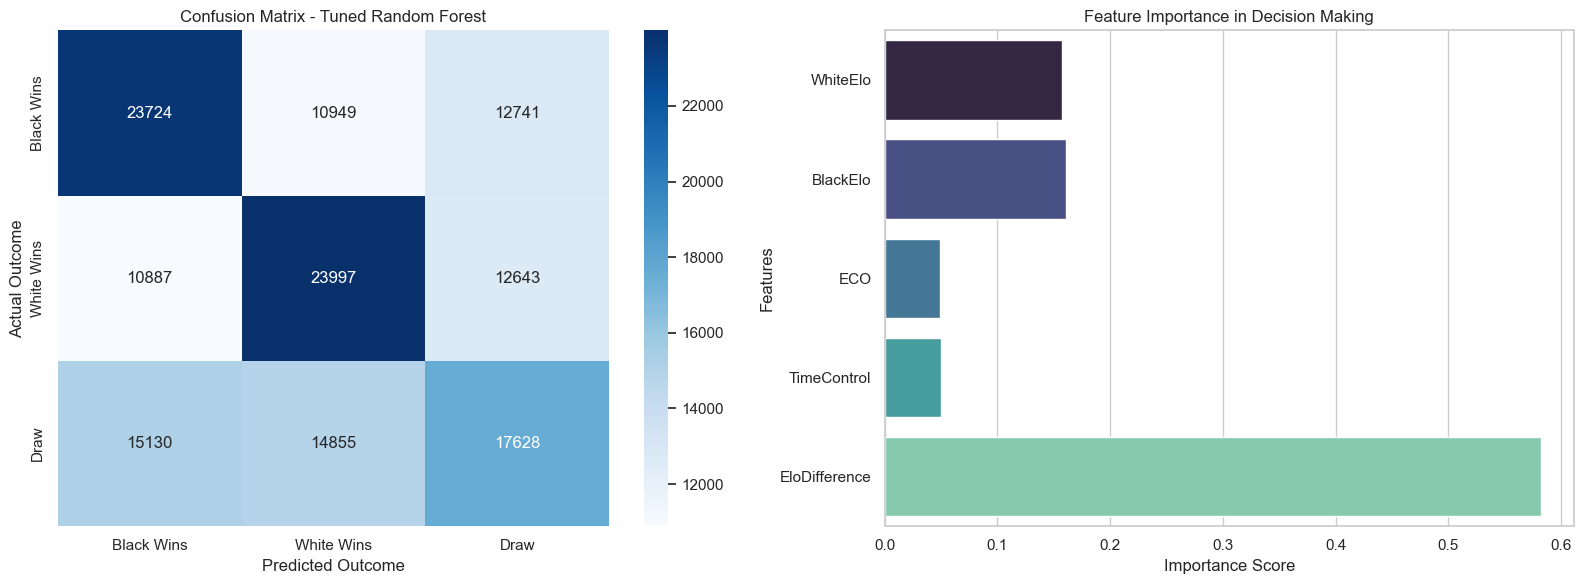

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tuned)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Black Wins', 'White Wins', 'Draw'], 
            yticklabels=['Black Wins', 'White Wins', 'Draw'])
axes[0].set_title('Confusion Matrix - Tuned Random Forest')
axes[0].set_ylabel('Actual Outcome')
axes[0].set_xlabel('Predicted Outcome')

# 2. Feature Importances
importances = rf_model_tuned.feature_importances_
feature_names = X.columns

sns.barplot(x=importances, y=feature_names, ax=axes[1], hue=feature_names, legend=False, palette='mako')
axes[1].set_title('Feature Importance in Decision Making')
axes[1].set_xlabel('Importance Score')
axes[1].set_ylabel('Features')

plt.tight_layout()
plt.show()

In [28]:
import joblib

# Save the tuned model, scaler, and label encoders to files WITH COMPRESSION
joblib.dump(rf_model_tuned, 'chess_rf_model.pkl', compress=3) # Creates a compressed ZLIB file
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_eco, 'le_eco.pkl')
joblib.dump(le_time, 'le_time.pkl')

print("Model and preprocessors saved with compression successfully!")

Model and preprocessors saved with compression successfully!


---
## 11. Improvements
The following section adds three key improvements over the baseline:
1. **New features** — `AbsEloDifference`, `TimeCategory` (Bullet/Blitz/Rapid/Classical), `ECO_Family` (opening group A–E), and `DrawLikelihood` (flag for closely matched games)
2. **`class_weight='balanced'`** on Random Forest — uses all data instead of downsampling
3. **XGBoost** — gradient boosting typically outperforms Random Forest on tabular data

In [ ]:
## 11.1 Feature Engineering on the FULL cleaned dataset (no downsampling needed)

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Re-use df_raw from earlier cells; re-apply cleaning steps cleanly
df_imp = df_raw.copy()
df_imp['EloDifference'] = df_imp['WhiteElo'] - df_imp['BlackElo']
df_imp = df_imp[df_imp['TimeControl'] != '-']
df_imp = df_imp[df_imp['Result'] != '*']
df_imp = df_imp.dropna(subset=['WhiteElo','BlackElo','ECO','TimeControl','Result'])

# --- New features ---

# 1. Absolute Elo difference (captures magnitude regardless of direction)
df_imp['AbsEloDiff'] = df_imp['EloDifference'].abs()

# 2. Draw likelihood flag — closely matched players draw more often
df_imp['CloseMatch'] = (df_imp['AbsEloDiff'] < 100).astype(int)

# 3. ECO family (opening group: A/B/C/D/E)
df_imp['ECO_Family'] = df_imp['ECO'].str[0]
# ECO_Family: ordinal A=0, B=1, C=2, D=3, E=4 (matches app.py)
df_imp['ECO_Family'] = df_imp['ECO_Family'].apply(
    lambda x: max(0, min(ord(str(x).upper()) - ord('A'), 4))
)

# 4. Time category (Bullet < 180s, Blitz < 600s, Rapid < 1800s, Classical+)
def time_category(tc):
    try:
        parts = tc.split('+')
        base = int(parts[0])
        inc = int(parts[1]) if len(parts) > 1 else 0
        est = base + inc * 40
        if est < 180:   return 0  # Bullet
        elif est < 600:  return 1  # Blitz
        elif est < 1800: return 2  # Rapid
        else:            return 3  # Classical
    except:
        return 1  # default Blitz

df_imp['TimeCategory'] = df_imp['TimeControl'].apply(time_category)

# Encode remaining categoricals
le_result2 = LabelEncoder()
df_imp['Result'] = le_result2.fit_transform(df_imp['Result'])

le_eco2 = LabelEncoder()
df_imp['ECO'] = le_eco2.fit_transform(df_imp['ECO'])

le_time2 = LabelEncoder()
df_imp['TimeControl'] = le_time2.fit_transform(df_imp['TimeControl'])

print('Features added. Dataset shape:', df_imp.shape)
print(df_imp[['WhiteElo','BlackElo','ECO','TimeControl','EloDifference',
              'AbsEloDiff','CloseMatch','ECO_Family','TimeCategory','Result']].head())

In [ ]:
## 11.2 Balanced 3-way equal sampling + Train/Test split
# Equal samples per class using all draws + downsampled wins/losses

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

FEATURES = ["WhiteElo", "BlackElo", "ECO", "TimeControl", "EloDifference",
            "AbsEloDiff", "CloseMatch", "ECO_Family", "TimeCategory"]

df_b = df_imp[df_imp["Result"] == 0]
df_w = df_imp[df_imp["Result"] == 1]
df_d = df_imp[df_imp["Result"] == 2]

print(f"Original: Black={len(df_b)}, White={len(df_w)}, Draw={len(df_d)}")

n = len(df_d)
df_b_s = resample(df_b, replace=False, n_samples=n, random_state=42)
df_w_s = resample(df_w, replace=False, n_samples=n, random_state=42)

df_bal = pd.concat([df_b_s, df_w_s, df_d]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Balanced: {n} per class, total={len(df_bal)}")
print(df_bal["Result"].value_counts())

X2 = df_bal[FEATURES]
y2 = df_bal["Result"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled  = scaler2.transform(X2_test)

print(f"Train: {X2_train.shape}, Test: {X2_test.shape}")


In [ ]:
## 11.3 Random Forest with new features (balanced dataset)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

print("Training RF with new features...")

rf_improved = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_improved.fit(X2_train_scaled, y2_train)
y2_pred_rf = rf_improved.predict(X2_test_scaled)

print("=" * 50)
print(" RF + NEW FEATURES (balanced dataset)")
print("=" * 50)
print(classification_report(y2_test, y2_pred_rf,
      target_names=["Black Wins", "White Wins", "Draw"]))


In [ ]:
## 11.4 XGBoost with new features (balanced dataset)

from xgboost import XGBClassifier
from sklearn.metrics import classification_report

print("Training XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X2_train_scaled, y2_train)
y2_pred_xgb = xgb_model.predict(X2_test_scaled)

print("=" * 50)
print("          XGBOOST RESULTS")
print("=" * 50)
print(classification_report(y2_test, y2_pred_xgb,
      target_names=["Black Wins", "White Wins", "Draw"]))


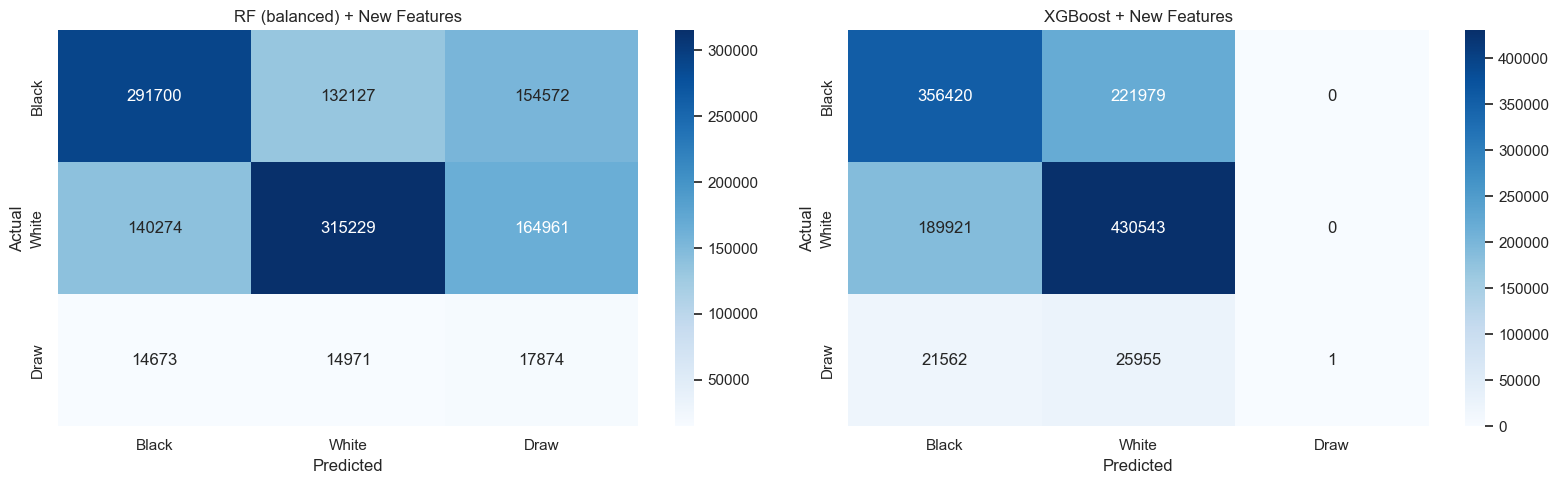

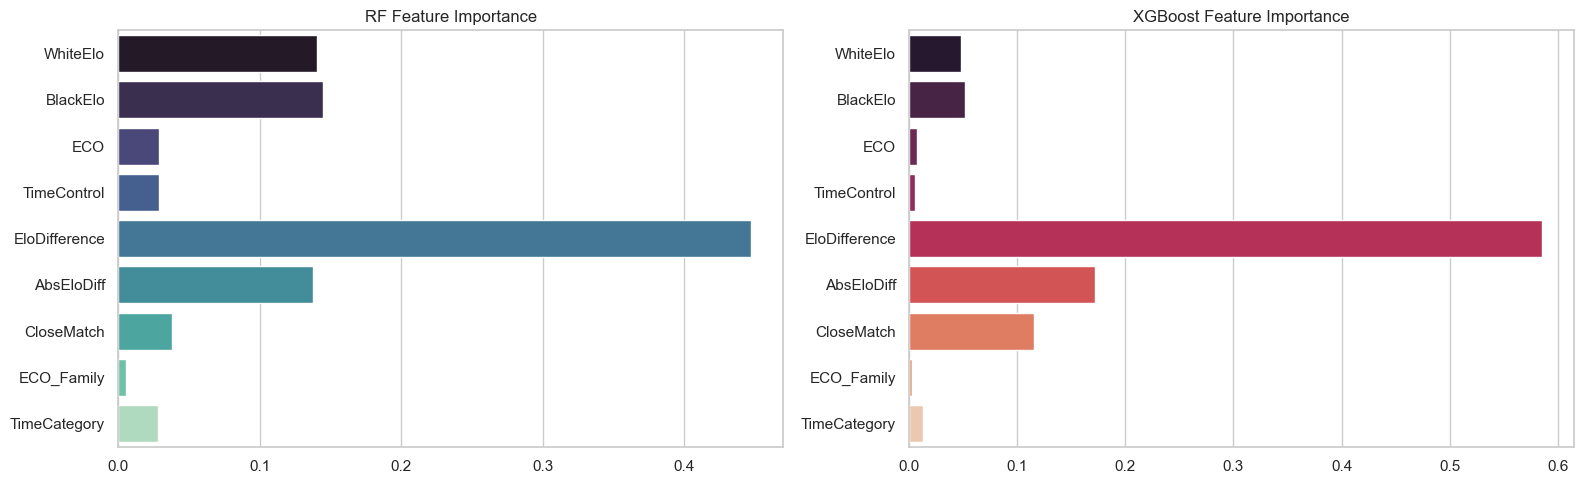

In [33]:
## 11.5 Compare all models side-by-side

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, preds, title in zip(
    axes,
    [y2_pred_rf, y2_pred_xgb],
    ['RF (balanced) + New Features', 'XGBoost + New Features']
):
    cm = confusion_matrix(y2_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Black', 'White', 'Draw'],
                yticklabels=['Black', 'White', 'Draw'])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Feature importance comparison
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))
feature_names = FEATURES

sns.barplot(x=rf_improved.feature_importances_, y=feature_names,
            ax=axes2[0], hue=feature_names, legend=False, palette='mako')
axes2[0].set_title('RF Feature Importance')

sns.barplot(x=xgb_model.feature_importances_, y=feature_names,
            ax=axes2[1], hue=feature_names, legend=False, palette='rocket')
axes2[1].set_title('XGBoost Feature Importance')

plt.tight_layout()
plt.show()

In [34]:
## 11.6 Save the best model (XGBoost) + new preprocessors
# Update the pkl files so app.py picks up the improved model

import joblib

# Determine which model performed better
from sklearn.metrics import accuracy_score
rf_acc  = accuracy_score(y2_test, y2_pred_rf)
xgb_acc = accuracy_score(y2_test, y2_pred_xgb)
print(f'RF accuracy:  {rf_acc:.4f}')
print(f'XGB accuracy: {xgb_acc:.4f}')

best_model = xgb_model if xgb_acc >= rf_acc else rf_improved
print(f'Saving: {type(best_model).__name__}')

joblib.dump(best_model, 'chess_rf_model.pkl', compress=3)
joblib.dump(scaler2,    'scaler.pkl')
joblib.dump(le_eco2,    'le_eco.pkl')
joblib.dump(le_time2,   'le_time.pkl')

print('Saved successfully!')

RF accuracy:  0.5013
XGB accuracy: 0.6314
Saving: XGBClassifier
Saved successfully!
